# Wycena historyczna opcji GOOG — LSM (Longstaff–Schwartz)

Notebook **backtestuje wycenę opcji z przeszłości** i porównuje ją z rzeczywistym wynikiem
przy wygaśnięciu. Kluczowa zasada: **zero look-ahead bias** — parametry modelu pochodzą
wyłącznie z informacji dostępnych w **dniu wyceny** $t_0$:

| Parametr | Źródło w $t_0$ |
|----------|----------------|
| $S_0$ | Cena zamknięcia GOOG w $t_0$ |
| $\sigma$ | Zmienność historyczna z ostatnich 252 sesji **kończących się** w $t_0$ |
| $r$ | Stopa ^IRX (13T Treasury) w $t_0$ |
| $T$ | Czas do wygaśnięcia kontraktu (znany z kalendarza) |

**Porównanie wycen:**
1. **LSM** — opcja amerykańska (Longstaff–Schwartz),
2. **Black–Scholes** — opcja europejska (benchmark),
3. **Wypłata zrealizowana** — rzeczywista wypłata przy wygaśnięciu $T$, zdyskontowana do $t_0$.

> Yahoo Finance nie udostępnia historycznych kotowań opcji, dlatego jako „prawdę ex-post”
> stosujemy zrealizowaną wypłatę intrinsic przy wygaśnięciu.

In [11]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Styl pod tryb ciemny ---
DARK_BG = "#1a1a2e"
DARK_AXES = "#16213e"
DARK_GRID = "#3a3a5c"
DARK_TEXT = "#e8e8f0"
DARK_MUTED = "#9898b0"

COLORS = {
    "lsm": "#5dade2",       # jasny niebieski
    "bs": "#f5b041",        # jasny pomarańcz
    "realized": "#ec7063",  # koralowy
    "put": "#5dade2",
    "call": "#58d68d",      # zielony
    "spot": "#aeb6bf",
    "zero": "#7f8c8d",
    "error_pos": "#e74c3c",
    "error_neg": "#2ecc71",
}

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_AXES,
    "axes.edgecolor": DARK_GRID,
    "axes.labelcolor": DARK_TEXT,
    "axes.titlecolor": "#ffffff",
    "axes.titleweight": "bold",
    "text.color": DARK_TEXT,
    "xtick.color": DARK_MUTED,
    "ytick.color": DARK_MUTED,
    "grid.color": DARK_GRID,
    "grid.alpha": 0.55,
    "legend.facecolor": DARK_AXES,
    "legend.edgecolor": DARK_GRID,
    "legend.labelcolor": DARK_TEXT,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TICKER = "GOOG"
RNG_SEED = 42
VOL_LOOKBACK = 252   # dni handlowe do estymacji σ
M_STEPS = 126
N_PATHS = 20_000

## 1. Dane historyczne i scenariusze backtestu

In [12]:
def _normalize_index(df: pd.DataFrame) -> pd.DataFrame:
    """Usuwa strefę czasową z indeksu dat."""
    out = df.copy()
    if isinstance(out.index, pd.DatetimeIndex) and out.index.tz is not None:
        out.index = out.index.tz_localize(None)
    return out.sort_index()


def pobierz_historie(ticker: str = TICKER, lata: int = 3) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Pobiera historię cen akcji i stopy ^IRX."""
    start = (datetime.now().replace(year=datetime.now().year - lata)).strftime("%Y-%m-%d")
    spot = _normalize_index(yf.Ticker(ticker).history(start=start))
    irx = _normalize_index(yf.Ticker("^IRX").history(start=start))
    if spot.empty:
        raise RuntimeError(f"Brak historii dla {ticker}")
    return spot, irx


def sigma_w_dniu(spot: pd.DataFrame, data_wyceny: pd.Timestamp, lookback: int = VOL_LOOKBACK) -> float:
    """Roczna σ z log-zwrotów — tylko dane do daty wyceny włącznie."""
    closes = spot.loc[:data_wyceny, "Close"].dropna()
    if len(closes) < 22:
        return np.nan
    window = closes.tail(lookback)
    log_rets = np.log(window / window.shift(1)).dropna()
    return float(log_rets.std() * np.sqrt(252))


def r_w_dniu(irx: pd.DataFrame, data_wyceny: pd.Timestamp, fallback: float = 0.04) -> float:
    """Stopa wolna od ryzyka w dniu wyceny (^IRX / 100)."""
    series = irx.loc[:data_wyceny, "Close"].dropna()
    if series.empty:
        return fallback
    return float(series.iloc[-1] / 100.0)


def S_w_dniu(spot: pd.DataFrame, data: pd.Timestamp) -> float:
    return float(spot.loc[:data, "Close"].iloc[-1])


def generuj_scenariusze(
    spot: pd.DataFrame,
    co_ile_sesji: int = 21,
    dni_do_exp_min: int = 18,
    dni_do_exp_max: int = 35,
) -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    """
    Tworzy pary (data_wyceny, data_wygasniecia) z przeszłości.
    Wygaśnięcie = ~25 sesji po dacie wyceny (musi być w przeszłości).
    """
    dates = spot.index
    today = pd.Timestamp(datetime.now().date())
    scenariusze = []

    i = VOL_LOOKBACK
    while i + dni_do_exp_min < len(dates):
        data_wyceny = dates[i]
        exp_idx = i + (dni_do_exp_min + dni_do_exp_max) // 2
        if exp_idx >= len(dates):
            break
        data_exp = dates[exp_idx]
        dni = (data_exp - data_wyceny).days
        if dni_do_exp_min <= dni <= dni_do_exp_max + 5 and data_exp < today:
            scenariusze.append((data_wyceny, data_exp))
        i += co_ile_sesji

    return scenariusze


spot_hist, irx_hist = pobierz_historie()
scenariusze = generuj_scenariusze(spot_hist)

print(f"Historia GOOG: {spot_hist.index[0].date()} → {spot_hist.index[-1].date()}  ({len(spot_hist)} sesji)")
print(f"Scenariusze backtestu: {len(scenariusze)}")
print(f"Zakres wycen: {scenariusze[0][0].date()} → {scenariusze[-1][0].date()}")
print(f"Przykład: wycena {scenariusze[-1][0].date()}, wygaśnięcie {scenariusze[-1][1].date()}")

Historia GOOG: 2023-05-25 → 2026-05-22  (751 sesji)
Scenariusze backtestu: 22
Zakres wycen: 2024-05-28 → 2026-04-01
Przykład: wycena 2026-04-01, wygaśnięcie 2026-05-08


## 2. Modele wyceny

In [13]:
def bs_european(S0: float, K: float, r: float, sigma: float, T: float, typ: str = "put") -> float:
    if T <= 0 or sigma <= 0:
        return max(K - S0, 0.0) if typ == "put" else max(S0 - K, 0.0)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if typ == "call":
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


def symuluj_sciezki_gbm(S0, r, sigma, T, M, N, seed=RNG_SEED):
    dt = T / M
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((N, M))
    log_increments = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.log(S0) + np.cumsum(log_increments, axis=1)
    return np.exp(np.concatenate([np.full((N, 1), np.log(S0)), log_paths], axis=1))


def lsm_longstaff_schwartz(
    S0, K, r, sigma, T, typ="put", M=M_STEPS, N=N_PATHS, seed=RNG_SEED,
):
    dt = T / M
    disc = np.exp(-r * dt)
    S = symuluj_sciezki_gbm(S0, r, sigma, T, M, N, seed)
    H = np.maximum(K - S, 0.0) if typ == "put" else np.maximum(S - K, 0.0)

    cashflow = H[:, -1].copy()
    exercise_time = np.full(N, M, dtype=int)

    for t in range(M - 1, 0, -1):
        itm = H[:, t] > 0
        if not np.any(itm):
            continue
        discount = disc ** (exercise_time - t)
        continuation = cashflow * discount
        X = S[itm, t]
        Y = continuation[itm]
        if len(X) < 10:
            continue
        A = np.column_stack([np.ones_like(X), X, X ** 2])
        beta, _, _, _ = np.linalg.lstsq(A, Y, rcond=1e-8)
        predicted = np.clip(A @ beta, 0.0, None)
        exercise_now = H[itm, t] > predicted
        for j, idx in enumerate(np.where(itm)[0]):
            if exercise_now[j]:
                cashflow[idx] = H[idx, t]
                exercise_time[idx] = t

    pv = cashflow * (disc ** exercise_time)
    return float(pv.mean()), float(pv.std(ddof=1) / np.sqrt(N))


def wypłata_zrealizowana(S_T: float, K: float, typ: str) -> float:
    return max(K - S_T, 0.0) if typ == "put" else max(S_T - K, 0.0)


def atm_strike(S0: float, krok: float = 5.0) -> float:
    return round(S0 / krok) * krok

## 3. Backtest — wycena ex-ante vs wynik ex-post

In [14]:
def uruchom_backtest(
    spot: pd.DataFrame,
    irx: pd.DataFrame,
    scenariusze: list,
    typy: list[str] = ("put", "call"),
    strikes_wzgl: list[float] = (0.0,),  # 0 = ATM, -0.05 = 5% OTM put
) -> pd.DataFrame:
    """
    Dla każdego scenariusza wycenia opcję w t₀ (tylko dane do t₀)
    i porównuje z zrealizowaną wypłatą przy wygaśnięciu.
    """
    rows = []
    for idx, (t0, t_exp) in enumerate(scenariusze):
        S0 = S_w_dniu(spot, t0)
        S_T = S_w_dniu(spot, t_exp)
        sigma = sigma_w_dniu(spot, t0)
        r = r_w_dniu(irx, t0)
        T = max((t_exp - t0).days / 365.0, 1 / 365)

        if np.isnan(sigma) or sigma <= 0:
            continue

        for offset in strikes_wzgl:
            K_base = atm_strike(S0)
            K = K_base * (1 + offset)
            K = round(K / 5) * 5

            for typ in typy:
                lsm, lsm_se = lsm_longstaff_schwartz(
                    S0, K, r, sigma, T, typ=typ, seed=RNG_SEED + idx * 10 + int(offset * 100)
                )
                bs = bs_european(S0, K, r, sigma, T, typ=typ)
                payoff = wypłata_zrealizowana(S_T, K, typ)
                payoff_pv = np.exp(-r * T) * payoff

                rows.append({
                    "data_wyceny": t0.date(),
                    "data_wygasniecia": t_exp.date(),
                    "T_lat": T,
                    "typ": typ.upper(),
                    "S0": S0,
                    "S_T": S_T,
                    "K": K,
                    "sigma": sigma,
                    "r": r,
                    "lsm": lsm,
                    "lsm_se": lsm_se,
                    "bs": bs,
                    "premia_amerykanska": lsm - bs,
                    "wypłata_rzeczywista": payoff,
                    "wypłata_zdyskontowana": payoff_pv,
                    "blad_lsm": lsm - payoff_pv,
                    "blad_bs": bs - payoff_pv,
                    "blad_lsm_pct": (lsm - payoff_pv) / max(payoff_pv, 0.01) * 100 if payoff_pv > 0.01 else np.nan,
                })

    return pd.DataFrame(rows)


print("Uruchamianie backtestu (ATM put + call)...")
wyniki = uruchom_backtest(spot_hist, irx_hist, scenariusze)
print(f"Gotowe: {len(wyniki)} wierszy, {wyniki['data_wyceny'].nunique()} dat wyceny")
wyniki

Uruchamianie backtestu (ATM put + call)...


/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/1206733281.py:43: RuntimeWarning: divide by zero encountered in matmul
  predicted = np.clip(A @ beta, 0.0, None)
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/1206733281.py:43: RuntimeWarning: overflow encountered in matmul
  predicted = np.clip(A @ beta, 0.0, None)
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/1206733281.py:43: RuntimeWarning: invalid value encountered in matmul
  predicted = np.clip(A @ beta, 0.0, None)


Gotowe: 44 wierszy, 22 dat wyceny


,data_wyceny,data_wygasniecia,T_lat,typ,S0,S_T,K,sigma,r,lsm,lsm_se,bs,premia_amerykanska,wypłata_rzeczywista,wypłata_zdyskontowana,blad_lsm,blad_bs,blad_lsm_pct
0,2024-05-28,2024-07-05,0.104110,PUT,176.570374,190.613525,175,0.280253,0.05248,5.166184,0.046021,5.140034,0.026149,0.000000,0.000000,5.166184,5.140034,NaN
1,2024-05-28,2024-07-05,0.104110,CALL,176.570374,190.613525,175,0.280253,0.05248,7.592859,0.065900,7.663943,-0.071084,15.613525,15.528451,-7.935592,-7.864508,-51.103567
2,2024-06-27,2024-08-05,0.106849,PUT,185.549286,159.513214,185,0.275666,0.05223,5.862397,0.051656,5.879951,-0.017553,25.486786,25.344947,-19.482549,-19.464996,-76.869561
3,2024-06-27,2024-08-05,0.106849,CALL,185.549286,159.513214,185,0.275666,0.05223,7.433293,0.065627,7.458798,-0.025505,0.000000,0.000000,7.433293,7.458798,NaN
4,2024-07-29,2024-09-04,0.101370,PUT,169.929626,156.703049,170,0.274570,0.05147,5.537129,0.046893,5.512033,0.025096,13.296951,13.227755,-7.690626,-7.715722,-58.140073
5,2024-07-29,2024-09-04,0.101370,CALL,169.929626,156.703049,170,0.274570,0.05147,6.267090,0.057865,6.326326,-0.059236,0.000000,0.000000,6.267090,6.326326,NaN
6,2024-08-27,2024-10-03,0.101370,PUT,165.212967,166.255692,165,0.277407,0.04968,5.350702,0.045596,5.295084,0.055618,0.000000,0.000000,5.350702,5.295084,NaN
7,2024-08-27,2024-10-03,0.101370,CALL,165.212967,166.255692,165,0.277407,0.04968,6.152317,0.054298,6.336911,-0.184594,1.255692,1.249384,4.902934,5.087528,392.428179
8,2024-09-26,2024-11-01,0.098630,PUT,162.894989,171.664627,165,0.280494,0.04468,6.525551,0.049690,6.463028,0.062522,0.000000,0.000000,6.525551,6.463028,NaN
9,2024-09-26,2024-11-01,0.098630,CALL,162.894989,171.664627,165,0.280494,0.04468,4.999021,0.050359,5.083539,-0.084517,6.664627,6.635322,-1.636301,-1.551783,-24.660454


In [15]:
fmt = [
    "data_wyceny", "data_wygasniecia", "typ", "S0", "S_T", "K",
    "sigma", "lsm", "bs", "wypłata_zdyskontowana", "blad_lsm", "blad_bs",
]

print("=" * 100)
print("BACKTEST HISTORYCZNY — wycena ex-ante (wiedza z dnia wyceny) vs wypłata ex-post")
print("=" * 100)
print(wyniki[fmt].tail(12).to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

print("\n--- Metryki jakości wyceny (vs zdyskontowana wypłata rzeczywista) ---")
for typ in ["PUT", "CALL"]:
    sub = wyniki[wyniki["typ"] == typ]
    if sub.empty:
        continue
    for metoda, col in [("LSM", "blad_lsm"), ("BS", "blad_bs")]:
        err = sub[col]
        print(
            f"{typ:4s} {metoda:3s}: MAE={err.abs().mean():7.4f}  "
            f"RMSE={np.sqrt((err**2).mean()):7.4f}  bias={err.mean():+7.4f}"
        )

BACKTEST HISTORYCZNY — wycena ex-ante (wiedza z dnia wyceny) vs wypłata ex-post
data_wyceny data_wygasniecia  typ        S0       S_T   K     sigma       lsm        bs  wypłata_zdyskontowana  blad_lsm   blad_bs
 2025-10-29       2025-12-05  PUT  274.7970  321.6534 275    0.3219   10.7969   10.8013                 0.0000   10.7969   10.8013
 2025-10-29       2025-12-05 CALL  274.7970  321.6534 275    0.3219   11.5229   11.6362                46.4773  -34.9544  -34.8412
 2025-11-28       2026-01-07  PUT  319.6861  322.2030 320    0.3260   13.3628   13.2501                 0.0000   13.3628   13.2501
 2025-11-28       2026-01-07 CALL  319.6861  322.2030 320    0.3260   14.0682   14.2300                 2.1941   11.8741   12.0359
 2025-12-30       2026-02-06  PUT  314.3286  322.8726 315    0.3174   12.5423   12.5856                 0.0000   12.5423   12.5856
 2025-12-30       2026-02-06 CALL  314.3286  322.8726 315    0.3174   12.7471   13.0729                 7.8436    4.9035    5.2293
 20

## 4. Wizualizacja (tryb ciemny)

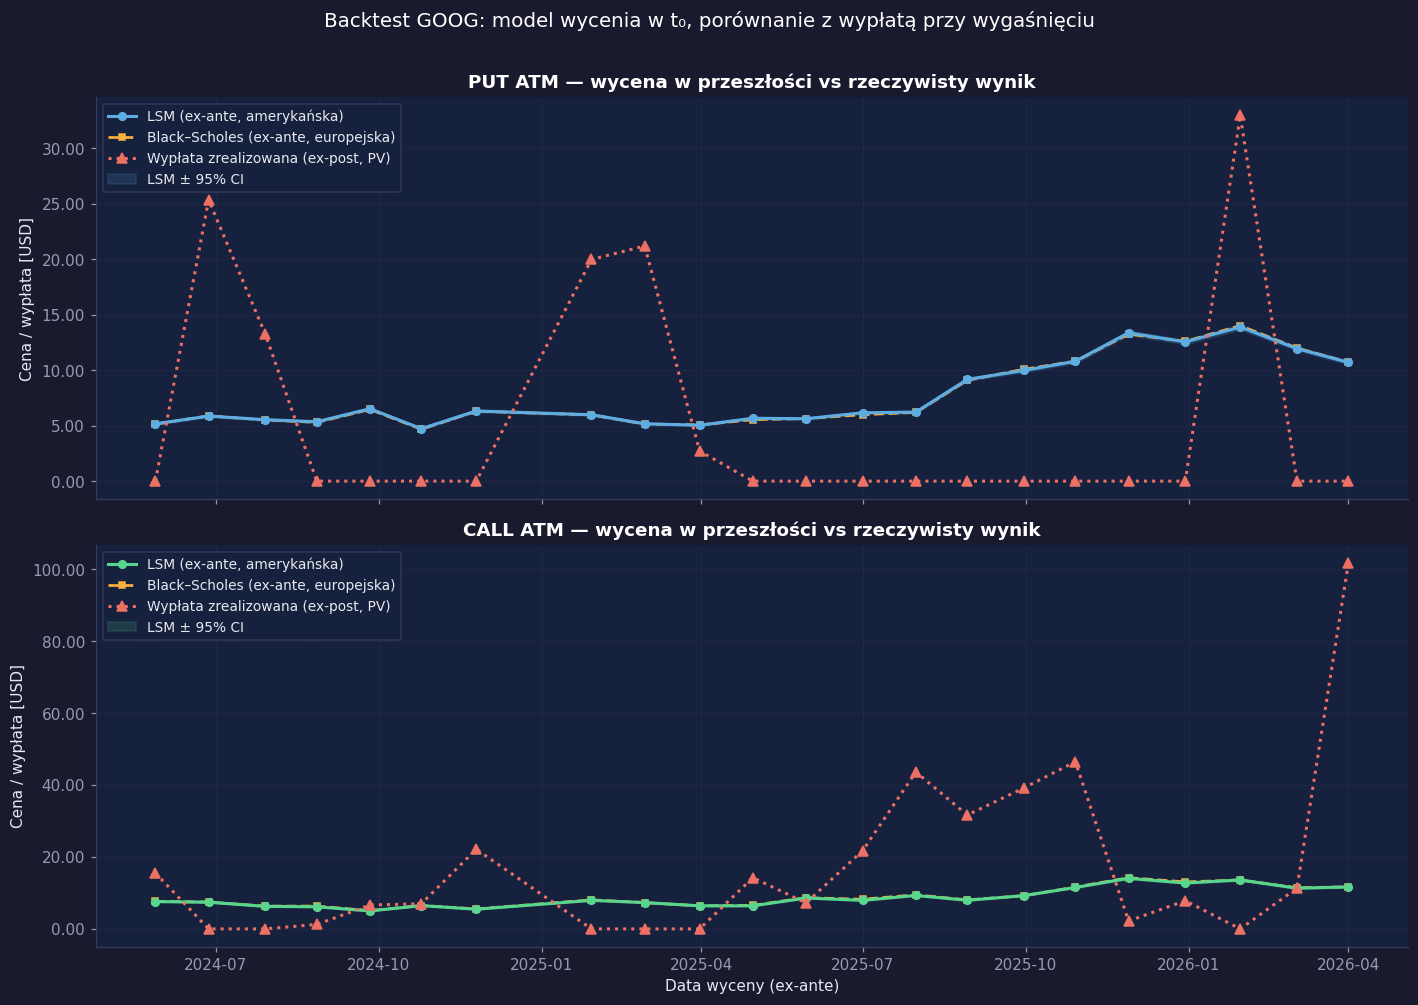

In [16]:
def _style_ax(ax):
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.tick_params(colors=DARK_MUTED)
    for spine in ax.spines.values():
        spine.set_color(DARK_GRID)


fig, axes = plt.subplots(+2, 1, figsize=(13, 9), sharex=True)
daty = pd.to_datetime(wyniki["data_wyceny"].unique())

for ax, typ, color_lsm, color_bs in zip(
    axes,
    ["PUT", "CALL"],
    [COLORS["put"], COLORS["call"]],
    [COLORS["bs"], COLORS["bs"]],
):
    sub = wyniki[wyniki["typ"] == typ].sort_values("data_wyceny")
    x = pd.to_datetime(sub["data_wyceny"])

    ax.plot(x, sub["lsm"], "o-", color=color_lsm, lw=2, ms=5,
            label="LSM (ex-ante, amerykańska)", zorder=3)
    ax.plot(x, sub["bs"], "s--", color=color_bs, lw=1.8, ms=4,
            label="Black–Scholes (ex-ante, europejska)", zorder=2)
    ax.plot(x, sub["wypłata_zdyskontowana"], "^:", color=COLORS["realized"], lw=2, ms=6,
            label="Wypłata zrealizowana (ex-post, PV)", zorder=4)

    ax.fill_between(x, sub["lsm"] - 1.96 * sub["lsm_se"], sub["lsm"] + 1.96 * sub["lsm_se"],
                    color=color_lsm, alpha=0.15, label="LSM ± 95% CI")
    ax.set_ylabel("Cena / wypłata [USD]")
    ax.set_title(f"{typ} ATM — wycena w przeszłości vs rzeczywisty wynik")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
    _style_ax(ax)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

axes[-1].set_xlabel("Data wyceny (ex-ante)")
fig.suptitle(
    f"Backtest {TICKER}: model wycenia w t₀, porównanie z wypłatą przy wygaśnięciu",
    fontsize=13, color="#ffffff", y=1.01,
)
plt.tight_layout()
plt.show()

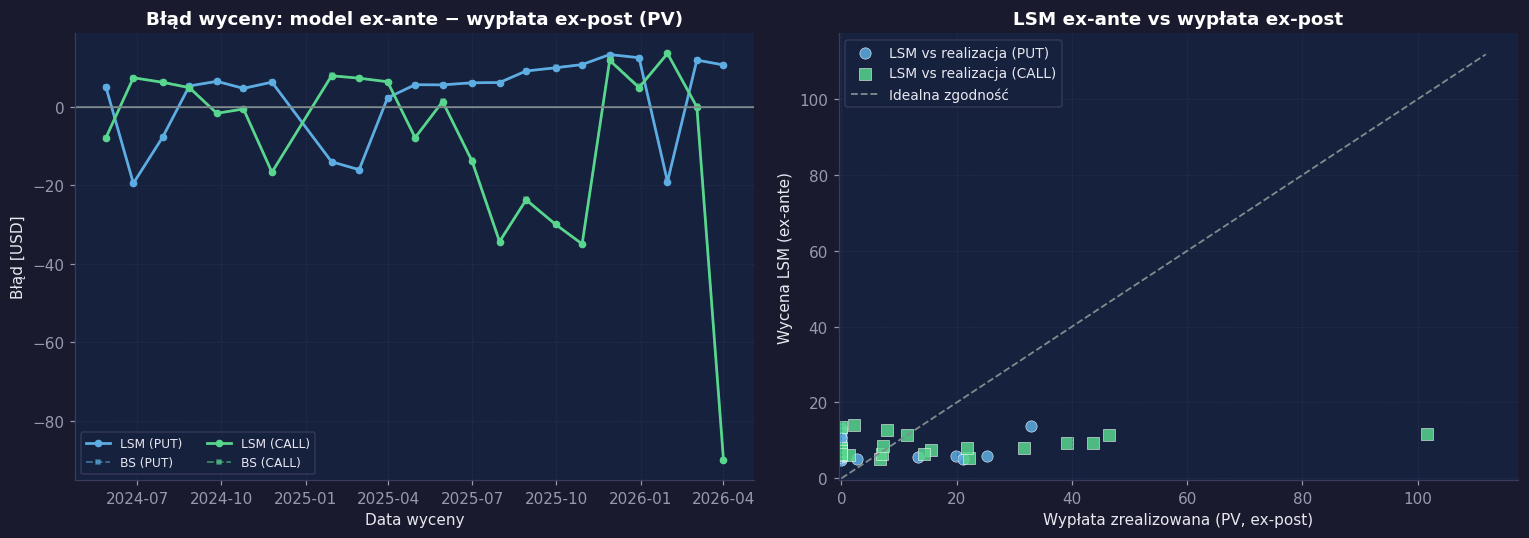

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: błąd wyceny w czasie
for typ, color in [("PUT", COLORS["put"]), ("CALL", COLORS["call"])]:
    sub = wyniki[wyniki["typ"] == typ].sort_values("data_wyceny")
    x = pd.to_datetime(sub["data_wyceny"])
    axes[0].plot(x, sub["blad_lsm"], "o-", color=color, lw=1.8, ms=4, label=f"LSM ({typ})")
    axes[0].plot(x, sub["blad_bs"], "s--", color=color, lw=1.2, ms=3, alpha=0.55, label=f"BS ({typ})")

axes[0].axhline(0, color=COLORS["zero"], lw=1)
axes[0].set_title("Błąd wyceny: model ex-ante − wypłata ex-post (PV)")
axes[0].set_xlabel("Data wyceny")
axes[0].set_ylabel("Błąd [USD]")
axes[0].legend(fontsize=8, ncol=2, framealpha=0.85)
axes[0].axhline(0, color=COLORS["zero"], lw=0.8)
_style_ax(axes[0])

# Wykres 2: scatter LSM vs wypłata
for typ, color, marker in [("PUT", COLORS["put"], "o"), ("CALL", COLORS["call"], "s")]:
    sub = wyniki[wyniki["typ"] == typ]
    axes[1].scatter(
        sub["wypłata_zdyskontowana"], sub["lsm"],
        c=color, s=55, alpha=0.85, marker=marker, edgecolors="#ffffff", linewidths=0.4,
        label=f"LSM vs realizacja ({typ})",
    )

lim_max = max(wyniki["wypłata_zdyskontowana"].max(), wyniki["lsm"].max()) * 1.1
axes[1].plot([0, lim_max], [0, lim_max], "--", color=COLORS["zero"], lw=1.2, label="Idealna zgodność")
axes[1].set_xlabel("Wypłata zrealizowana (PV, ex-post)")
axes[1].set_ylabel("Wycena LSM (ex-ante)")
axes[1].set_title("LSM ex-ante vs wypłata ex-post")
axes[1].legend(fontsize=9, framealpha=0.85)
axes[1].set_xlim(left=-0.5)
axes[1].set_ylim(bottom=-0.5)
_style_ax(axes[1])

plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\%'
<>:17: SyntaxWarning: invalid escape sequence '\%'
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6099/1147737269.py:17: SyntaxWarning: invalid escape sequence '\%'
  axes[2].set_ylabel("$r$ [\% rocznie]")


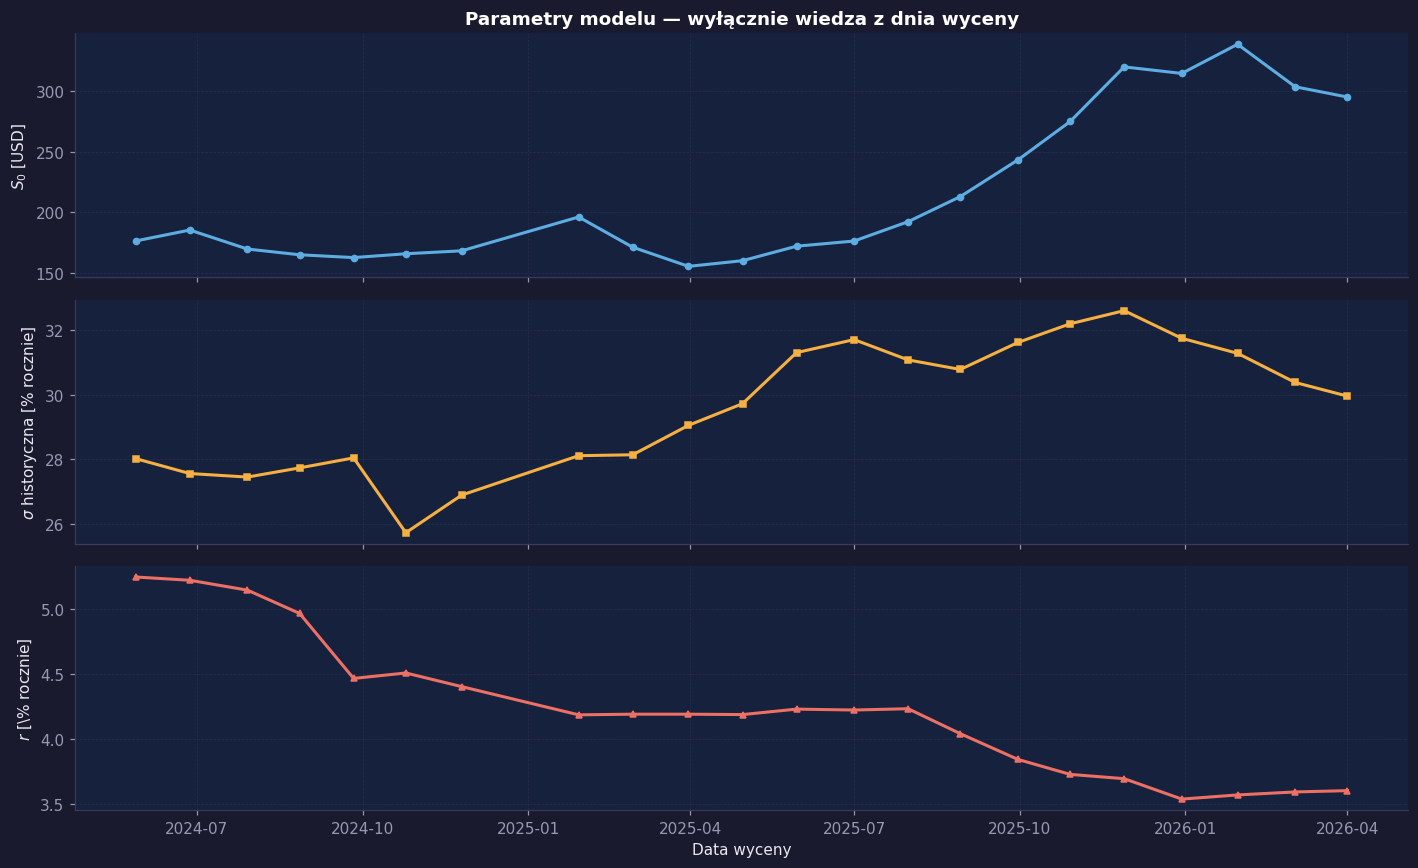

In [18]:
# Wykres parametrów ex-ante w czasie (weryfikacja braku look-ahead)
sub = wyniki[wyniki["typ"] == "PUT"].drop_duplicates("data_wyceny").sort_values("data_wyceny")
x = pd.to_datetime(sub["data_wyceny"])

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(x, sub["S0"], color=COLORS["lsm"], lw=2, marker="o", ms=4)
axes[0].set_ylabel("$S_0$ [USD]")
axes[0].set_title("Parametry modelu — wyłącznie wiedza z dnia wyceny")
_style_ax(axes[0])

axes[1].plot(x, sub["sigma"] * 100, color=COLORS["bs"], lw=2, marker="s", ms=4)
axes[1].set_ylabel("$\\sigma$ historyczna [% rocznie]")
_style_ax(axes[1])

axes[2].plot(x, sub["r"] * 100, color=COLORS["realized"], lw=2, marker="^", ms=4)
axes[2].set_ylabel("$r$ [\% rocznie]")
axes[2].set_xlabel("Data wyceny")
_style_ax(axes[2])

plt.tight_layout()
plt.show()

## 5. Analiza pojedynczego scenariusza (szczegóły)

PRZYKŁAD POJEDYNCZEJ WYCENY HISTORYCZNEJ
Data wyceny:         2026-04-01
Data wygaśnięcia:    2026-05-08
Czas do wygaśnięcia: 0.1014 lat (37 dni)

Parametry ex-ante (tylko dane do 2026-04-01):
  S₀ = 294.90 USD
  σ  = 29.96%  (252 sesje kończące się w dniu wyceny)
  r  = 3.61%  (^IRX w dniu wyceny)
  K  = 295 USD  (ATM)

Wynik ex-post (wygaśnięcie 2026-05-08):
  S_T = 397.05 USD
  Wypłata intrinsic = 0.0000 USD
  Wypłata PV        = 0.0000 USD

Wyceny ex-ante:
  LSM (amerykańska) = 10.6980 ± 0.1764
  BS  (europejska)  = 10.7168
  Premia ameryk.    = -0.0188

Błąd vs realizacja:
  LSM − PV = +10.6980 USD
  BS  − PV = +10.7168 USD


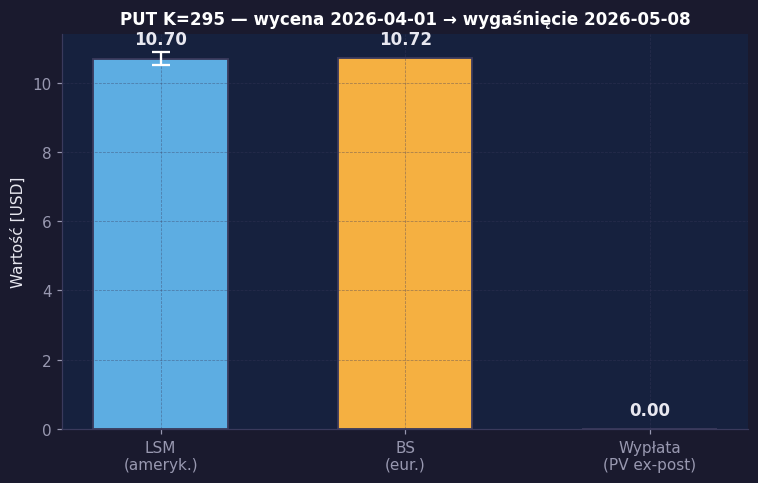

In [19]:
# Ostatni scenariusz — rozbicie na składowe
przyklad = wyniki[wyniki["typ"] == "PUT"].iloc[-1]

print("=" * 70)
print("PRZYKŁAD POJEDYNCZEJ WYCENY HISTORYCZNEJ")
print("=" * 70)
print(f"Data wyceny:         {przyklad['data_wyceny']}")
print(f"Data wygaśnięcia:    {przyklad['data_wygasniecia']}")
print(f"Czas do wygaśnięcia: {przyklad['T_lat']:.4f} lat ({przyklad['T_lat']*365:.0f} dni)")
print(f"\nParametry ex-ante (tylko dane do {przyklad['data_wyceny']}):")
print(f"  S₀ = {przyklad['S0']:.2f} USD")
print(f"  σ  = {przyklad['sigma']:.2%}  (252 sesje kończące się w dniu wyceny)")
print(f"  r  = {przyklad['r']:.2%}  (^IRX w dniu wyceny)")
print(f"  K  = {przyklad['K']:.0f} USD  (ATM)")
print(f"\nWynik ex-post (wygaśnięcie {przyklad['data_wygasniecia']}):")
print(f"  S_T = {przyklad['S_T']:.2f} USD")
print(f"  Wypłata intrinsic = {przyklad['wypłata_rzeczywista']:.4f} USD")
print(f"  Wypłata PV        = {przyklad['wypłata_zdyskontowana']:.4f} USD")
print(f"\nWyceny ex-ante:")
print(f"  LSM (amerykańska) = {przyklad['lsm']:.4f} ± {1.96*przyklad['lsm_se']:.4f}")
print(f"  BS  (europejska)  = {przyklad['bs']:.4f}")
print(f"  Premia ameryk.    = {przyklad['premia_amerykanska']:.4f}")
print(f"\nBłąd vs realizacja:")
print(f"  LSM − PV = {przyklad['blad_lsm']:+.4f} USD")
print(f"  BS  − PV = {przyklad['blad_bs']:+.4f} USD")

# Wykres porównawczy dla tego scenariusza
labels = ["LSM\n(ameryk.)", "BS\n(eur.)", "Wypłata\n(PV ex-post)"]
values = [przyklad["lsm"], przyklad["bs"], przyklad["wypłata_zdyskontowana"]]
bar_colors = [COLORS["lsm"], COLORS["bs"], COLORS["realized"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=bar_colors, edgecolor=DARK_GRID, linewidth=1.2, width=0.55)
ax.errorbar(0, przyklad["lsm"], yerr=1.96 * przyklad["lsm_se"],
            fmt="none", ecolor="#ffffff", capsize=6, capthick=1.5, lw=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", color=DARK_TEXT, fontsize=11, fontweight="bold")
ax.set_ylabel("Wartość [USD]")
ax.set_title(
    f"PUT K={przyklad['K']:.0f} — wycena {przyklad['data_wyceny']} → wygaśnięcie {przyklad['data_wygasniecia']}",
    fontsize=11,
)
_style_ax(ax)
plt.tight_layout()
plt.show()

## Podsumowanie

| Element | Opis |
|---------|------|
| **Backtest historyczny** | Wycena w $t_0$ z parametrami z $t_0$, porównanie z wypłatą w $T$ |
| **Brak look-ahead** | $\sigma$, $r$, $S_0$ liczone wyłącznie z danych $\leq t_0$ |
| **LSM** | Amerykańska opcja — uwzględnia optymalne wczesne wykonanie |
| **Black–Scholes** | Europejska opcja — dolne ograniczenie, bez wczesnego wykonania |
| **Wypłata zrealizowana** | Ex-post ground truth (Yahoo nie ma historycznych kotowań opcji) |

**Interpretacja błędów:**
- Duży dodatni błąd → model **przecenił** opcję względem tego, co faktycznie wypłacono.
- Duży ujemny błąd → model **niedoszacował** wartość (np. duży ruch ceny po wycenie).
- GBM + stała $\sigma$ historyczna to uproszczenie — odchylenia są oczekiwane.